# Feature Importance and Final Results

In this notebook, the final regression and classification results are summarized.

The best-performing models are identified based on evaluation metrics.

Feature importance analysis is performed to understand which health and lifestyle indicators are most useful for predicting stress level.

This notebook supports the final discussion, conclusion, report, and presentation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Step 1: Loading Processed Dataset and Model Results

In this step, the processed dataset and the saved model comparison result files are loaded.

The processed dataset will be used for feature importance analysis.

The saved result tables will be used to summarize regression and classification model performance.

In [2]:
PROJECT_DIR = Path(r"C:\Users\onury\OneDrive\Masaüstü\Machine Learning\ML-Stress-Level-Prediction")

processed_path = PROJECT_DIR / "data" / "processed" / "processed_health_indicators.csv"
regression_results_path = PROJECT_DIR / "reports" / "regression_model_results.csv"
classification_results_path = PROJECT_DIR / "reports" / "classification_model_results.csv"

df = pd.read_csv(processed_path)

df.head()

,age,steps_per_day,active_minutes,sedentary_minutes,sleep_hours,sleep_quality,stress_level,workouts_per_week,diet_quality,hydration_liters,...,heart_rate_avg,consistency_score,lifestyle_category_Athlete,lifestyle_category_Sedentary,fitness_level_Moderate,fitness_level_Unfit,activity_ratio,sleep_deficit,heart_rate_difference,stress_category
0,56,12633,122,1084,8.65,8.67,4.42,2,5.61,2.14,...,103.0,3.84,False,False,True,False,0.101161,0.65,48.2,Medium
1,46,1980,33,1122,5.97,5.37,7.91,2,8.17,0.92,...,126.3,7.25,False,False,False,True,0.028571,2.03,51.1,High
2,32,7139,60,1049,6.23,7.15,4.20,0,3.47,2.67,...,101.4,5.77,False,True,False,True,0.054103,1.77,35.1,Medium
3,60,4814,66,1018,5.09,7.61,7.12,4,5.26,2.17,...,107.8,9.11,False,False,True,False,0.060886,2.91,43.2,High
4,25,8096,86,1031,5.49,5.57,3.88,3,2.60,2.91,...,92.8,7.55,False,False,True,False,0.076992,2.51,28.8,Low


In [3]:
print("Processed dataset shape:", df.shape)

print("\nColumns:")
for col in df.columns:
    print("-", col)

Processed dataset shape: (1000000, 22)

Columns:
- age
- steps_per_day
- active_minutes
- sedentary_minutes
- sleep_hours
- sleep_quality
- stress_level
- workouts_per_week
- diet_quality
- hydration_liters
- bmi
- heart_rate_resting
- heart_rate_avg
- consistency_score
- lifestyle_category_Athlete
- lifestyle_category_Sedentary
- fitness_level_Moderate
- fitness_level_Unfit
- activity_ratio
- sleep_deficit
- heart_rate_difference
- stress_category


In [4]:
regression_results = pd.read_csv(regression_results_path)
classification_results = pd.read_csv(classification_results_path)

print("Regression Results:")
display(regression_results)

print("Classification Results:")
display(classification_results)

Regression Results:


,Model,MAE,RMSE,R2 Score
0,Gradient Boosting Regressor,0.780272,1.029622,0.684136
1,Random Forest Regressor,0.791427,1.047085,0.673330
2,Decision Tree Regressor,0.794846,1.056754,0.667269
3,Linear Regression,1.140826,1.418970,0.400083


Classification Results:


,Model,Accuracy,Precision,Recall,F1-score
0,Gradient Boosting Classifier,0.768025,0.770264,0.768025,0.763588
1,Decision Tree Classifier,0.758150,0.761107,0.758150,0.752715
2,Random Forest Classifier,0.754570,0.765302,0.754570,0.746040
3,Logistic Regression,0.718595,0.722247,0.718595,0.710867


# Step 2: Final Model Selection

In this step, the best regression and classification models are selected based on the model comparison results.

For regression, the model with the highest R² score and lowest error values is selected.

For classification, the model with the highest F1-score and accuracy is selected.

In [5]:
best_regression_model = regression_results.sort_values(by="R2 Score", ascending=False).iloc[0]
best_classification_model = classification_results.sort_values(by="F1-score", ascending=False).iloc[0]

print("Best Regression Model:")
print(best_regression_model)

print("\nBest Classification Model:")
print(best_classification_model)

Best Regression Model:
Model       Gradient Boosting Regressor
MAE                            0.780272
RMSE                           1.029622
R2 Score                       0.684136
Name: 0, dtype: object

Best Classification Model:
Model        Gradient Boosting Classifier
Accuracy                         0.768025
Precision                        0.770264
Recall                           0.768025
F1-score                         0.763588
Name: 0, dtype: object


## Interpretation of Final Model Selection

Based on the regression results, Gradient Boosting Regressor was selected as the best regression model because it achieved the highest R² score and the lowest prediction errors.

Based on the classification results, Gradient Boosting Classifier was selected as the best classification model because it achieved the highest accuracy and weighted F1-score.

These results show that Gradient Boosting performed best for both numerical stress level prediction and categorical stress classification.

# Step 3: Preparing Data for Feature Importance

In this step, the input features and target variables are prepared for feature importance analysis.

The same input features are used for both regression and classification tasks.

For regression, the target variable is `stress_level`.

For classification, the target variable is `stress_category`.

Both target-related columns are removed from the input features to avoid data leakage.

In [6]:
X = df.drop(columns=["stress_level", "stress_category"])

y_regression = df["stress_level"]
y_classification = df["stress_category"]

print("X shape:", X.shape)
print("Regression target shape:", y_regression.shape)
print("Classification target shape:", y_classification.shape)

print("stress_level in X:", "stress_level" in X.columns)
print("stress_category in X:", "stress_category" in X.columns)

X shape: (1000000, 20)
Regression target shape: (1000000,)
Classification target shape: (1000000,)
stress_level in X: False
stress_category in X: False


# Step 4: Sampling for Feature Importance

Since the dataset contains 1,000,000 rows, a random sample is used for feature importance analysis.

This reduces computation time while still providing a representative subset of the dataset.

A sample of 200,000 records is used for training and evaluating feature importance models.

In [7]:
feature_importance_sample = df.sample(n=200000, random_state=42)

X_sample = feature_importance_sample.drop(columns=["stress_level", "stress_category"])
y_reg_sample = feature_importance_sample["stress_level"]
y_cls_sample = feature_importance_sample["stress_category"]

print("X_sample shape:", X_sample.shape)
print("y_reg_sample shape:", y_reg_sample.shape)
print("y_cls_sample shape:", y_cls_sample.shape)

X_sample shape: (200000, 20)
y_reg_sample shape: (200000,)
y_cls_sample shape: (200000,)


# Step 5: Train-Test Split for Feature Importance

The sampled dataset is split into training and testing sets.

The training set is used to train the Gradient Boosting models.

The testing set is used to calculate permutation importance.

In [8]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_sample,
    y_reg_sample,
    test_size=0.2,
    random_state=42
)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_sample,
    y_cls_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_cls_sample
)

print("Regression train shape:", X_train_reg.shape)
print("Regression test shape:", X_test_reg.shape)

print("\nClassification train shape:", X_train_cls.shape)
print("Classification test shape:", X_test_cls.shape)

Regression train shape: (160000, 20)
Regression test shape: (40000, 20)

Classification train shape: (160000, 20)
Classification test shape: (40000, 20)


## Interpretation of Feature Importance Data Preparation

The dataset was successfully prepared for feature importance analysis.

The input feature matrix contains 20 features, and both target-related columns, `stress_level` and `stress_category`, were removed to avoid data leakage.

Because the full dataset contains 1,000,000 rows, a random sample of 200,000 rows was selected for feature importance analysis.

The sampled data was split into training and testing sets. For both regression and classification, 160,000 records were used for training and 40,000 records were used for testing.

# Step 6: Training Best Models for Feature Importance

In this step, the best-performing regression and classification models are trained again on the sampled dataset.

Gradient Boosting Regressor is used for numerical stress level prediction.

Gradient Boosting Classifier is used for categorical stress level prediction.

These trained models will be used for permutation importance analysis.

In [9]:
gb_reg_model = HistGradientBoostingRegressor(
    max_iter=100,
    max_leaf_nodes=31,
    learning_rate=0.1,
    random_state=42
)

gb_reg_model.fit(X_train_reg, y_train_reg)

y_pred_reg = gb_reg_model.predict(X_test_reg)

mae_reg = mean_absolute_error(y_test_reg, y_pred_reg)
rmse_reg = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2_reg = r2_score(y_test_reg, y_pred_reg)

print("Gradient Boosting Regressor on Sample")
print("MAE:", mae_reg)
print("RMSE:", rmse_reg)
print("R² Score:", r2_reg)

Gradient Boosting Regressor on Sample
MAE: 0.7855336260842951
RMSE: 1.0391237621844576
R² Score: 0.6778811572170232


In [10]:
gb_cls_model = HistGradientBoostingClassifier(
    max_iter=100,
    max_leaf_nodes=31,
    learning_rate=0.1,
    random_state=42
)

gb_cls_model.fit(X_train_cls, y_train_cls)

y_pred_cls = gb_cls_model.predict(X_test_cls)

accuracy_cls = accuracy_score(y_test_cls, y_pred_cls)
precision_cls = precision_score(y_test_cls, y_pred_cls, average="weighted", zero_division=0)
recall_cls = recall_score(y_test_cls, y_pred_cls, average="weighted", zero_division=0)
f1_cls = f1_score(y_test_cls, y_pred_cls, average="weighted", zero_division=0)

print("Gradient Boosting Classifier on Sample")
print("Accuracy:", accuracy_cls)
print("Precision:", precision_cls)
print("Recall:", recall_cls)
print("F1-score:", f1_cls)

Gradient Boosting Classifier on Sample
Accuracy: 0.75975
Precision: 0.7624517594492021
Recall: 0.75975
F1-score: 0.7545478627317148


# Step 7: Permutation Importance for Regression

In this step, permutation importance is calculated for the Gradient Boosting Regressor.

Permutation importance measures how much model performance decreases when a feature is randomly shuffled.

If shuffling a feature causes a large drop in model performance, that feature is considered important.

In [11]:
from sklearn.inspection import permutation_importance

In [12]:
reg_importance = permutation_importance(
    gb_reg_model,
    X_test_reg,
    y_test_reg,
    scoring="r2",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

reg_importance_df = pd.DataFrame({
    "Feature": X_test_reg.columns,
    "Importance": reg_importance.importances_mean,
    "Importance Std": reg_importance.importances_std
}).sort_values(by="Importance", ascending=False)

reg_importance_df

,Feature,Importance,Importance Std
5,sleep_quality,1.075369,0.015431
12,consistency_score,0.943320,0.006712
16,fitness_level_Unfit,0.077106,0.001624
17,activity_ratio,0.011303,0.000535
7,diet_quality,0.007595,0.000131
1,steps_per_day,0.007131,0.000255
15,fitness_level_Moderate,0.006731,0.000293
6,workouts_per_week,0.002889,0.000116
18,sleep_deficit,0.002707,0.000171
9,bmi,0.001210,0.000068


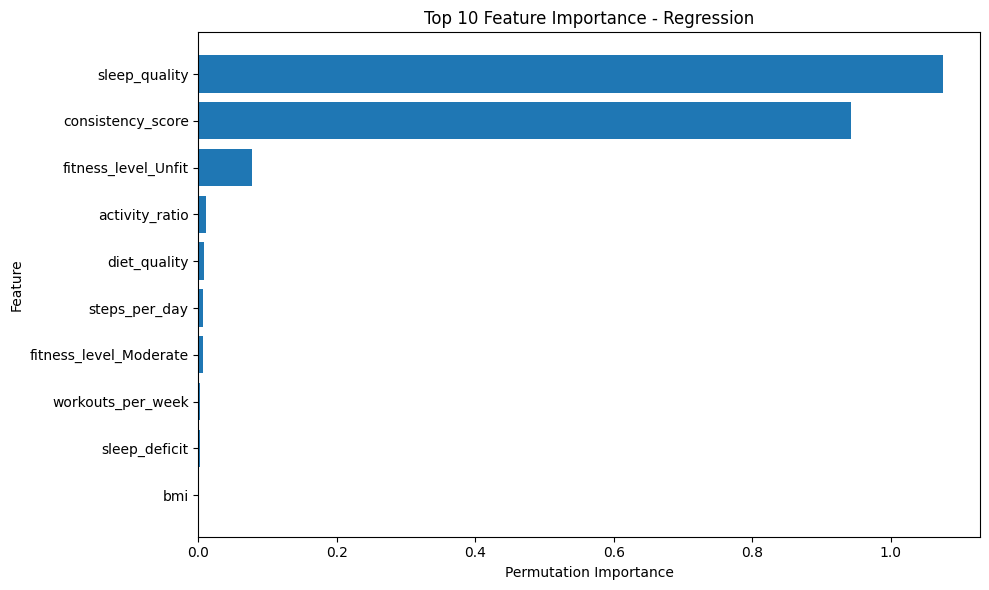

In [13]:
top_reg_features = reg_importance_df.head(10).sort_values(by="Importance")

plt.figure(figsize=(10, 6))

plt.barh(top_reg_features["Feature"], top_reg_features["Importance"])

plt.title("Top 10 Feature Importance - Regression")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Interpretation of Sample Model Performance

The Gradient Boosting models were trained again on a random sample of 200,000 records for feature importance analysis.

The Gradient Boosting Regressor achieved an R² score of approximately 0.678 on the sampled test set. This result is close to the full dataset regression performance, which shows that the sample is representative enough for feature importance analysis.

The Gradient Boosting Classifier achieved an accuracy of approximately 75.98% and a weighted F1-score of approximately 0.755 on the sampled test set. This is also close to the full dataset classification results.

Therefore, the sampled dataset can be used for feature importance analysis without significantly changing the overall model behavior.

## Interpretation of Regression Feature Importance

The permutation importance results show that `sleep_quality` is the most important feature for predicting the numerical `stress_level` value.

The second most important feature is `consistency_score`, which also has a strong impact on regression performance.

The `fitness_level_Unfit` feature also contributes to the model, but its importance is much lower compared to `sleep_quality` and `consistency_score`.

Other features such as `activity_ratio`, `diet_quality`, `steps_per_day`, and `sleep_deficit` have smaller importance values.

Overall, the regression feature importance analysis suggests that sleep quality and consistency-related behavior are the strongest predictors of numerical stress level in this dataset.

# Step 8: Permutation Importance for Classification

In this step, permutation importance is calculated for the Gradient Boosting Classifier.

The goal is to identify which features are most important for predicting the categorical `stress_category` variable.

Weighted F1-score is used as the scoring metric because the target classes are not perfectly balanced.

In [14]:
cls_importance = permutation_importance(
    gb_cls_model,
    X_test_cls,
    y_test_cls,
    scoring="f1_weighted",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

cls_importance_df = pd.DataFrame({
    "Feature": X_test_cls.columns,
    "Importance": cls_importance.importances_mean,
    "Importance Std": cls_importance.importances_std
}).sort_values(by="Importance", ascending=False)

cls_importance_df

,Feature,Importance,Importance Std
12,consistency_score,0.278307,0.001324
5,sleep_quality,0.209941,0.000272
16,fitness_level_Unfit,0.023971,0.000349
17,activity_ratio,0.004615,0.000331
15,fitness_level_Moderate,0.003527,0.000252
1,steps_per_day,0.002996,0.000398
7,diet_quality,0.002122,0.000412
6,workouts_per_week,0.001231,0.000262
18,sleep_deficit,0.001097,0.000351
4,sleep_hours,0.001011,0.000256


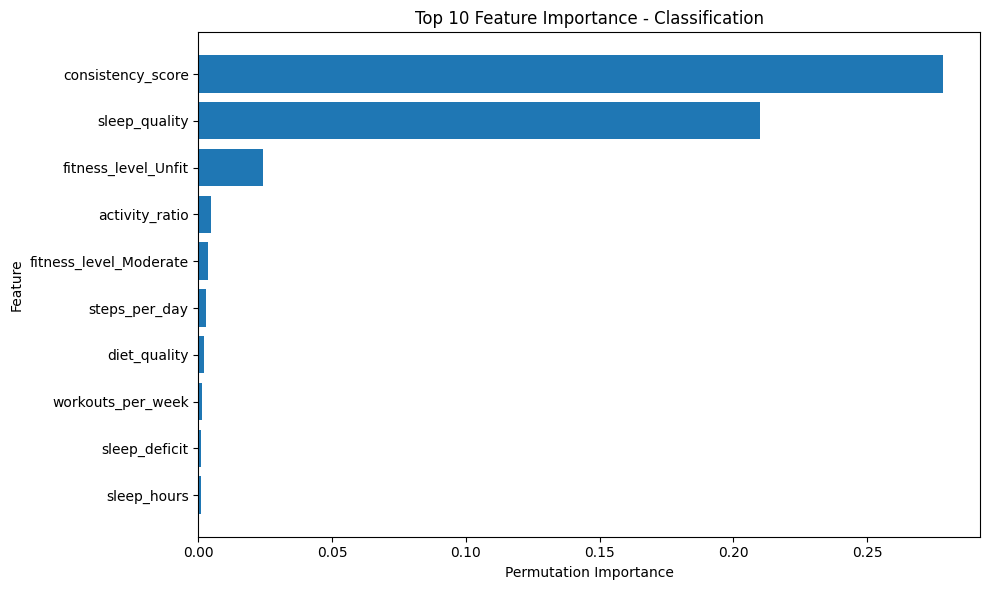

In [15]:
top_cls_features = cls_importance_df.head(10).sort_values(by="Importance")

plt.figure(figsize=(10, 6))

plt.barh(top_cls_features["Feature"], top_cls_features["Importance"])

plt.title("Top 10 Feature Importance - Classification")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Interpretation of Classification Feature Importance

The permutation importance results show that `consistency_score` is the most important feature for predicting the categorical `stress_category` variable.

The second most important feature is `sleep_quality`, which also has a strong impact on classification performance.

The `fitness_level_Unfit` feature also contributes to the model, but its importance is much lower compared to `consistency_score` and `sleep_quality`.

Other features such as `activity_ratio`, `fitness_level_Moderate`, `steps_per_day`, and `diet_quality` have smaller importance values.

Overall, the classification feature importance analysis suggests that consistency-related behavior and sleep quality are the strongest predictors for classifying stress level into Low, Medium, and High categories.

# Step 9: Comparing Regression and Classification Feature Importance

In this step, regression and classification feature importance results are compared.

This helps us understand whether the same features are important for predicting numerical stress level and categorical stress classes.

In [16]:
print("Top 10 Regression Features:")
display(reg_importance_df.head(10))

print("Top 10 Classification Features:")
display(cls_importance_df.head(10))

Top 10 Regression Features:


,Feature,Importance,Importance Std
5,sleep_quality,1.075369,0.015431
12,consistency_score,0.943320,0.006712
16,fitness_level_Unfit,0.077106,0.001624
17,activity_ratio,0.011303,0.000535
7,diet_quality,0.007595,0.000131
1,steps_per_day,0.007131,0.000255
15,fitness_level_Moderate,0.006731,0.000293
6,workouts_per_week,0.002889,0.000116
18,sleep_deficit,0.002707,0.000171
9,bmi,0.001210,0.000068


Top 10 Classification Features:


,Feature,Importance,Importance Std
12,consistency_score,0.278307,0.001324
5,sleep_quality,0.209941,0.000272
16,fitness_level_Unfit,0.023971,0.000349
17,activity_ratio,0.004615,0.000331
15,fitness_level_Moderate,0.003527,0.000252
1,steps_per_day,0.002996,0.000398
7,diet_quality,0.002122,0.000412
6,workouts_per_week,0.001231,0.000262
18,sleep_deficit,0.001097,0.000351
4,sleep_hours,0.001011,0.000256


## Interpretation of Feature Importance Comparison

The feature importance results show that `sleep_quality` and `consistency_score` are the two most important features in both regression and classification tasks.

For regression, `sleep_quality` is the most important feature, followed by `consistency_score`.

For classification, `consistency_score` is the most important feature, followed by `sleep_quality`.

This indicates that sleep quality and consistency-related behavior are strongly related to stress prediction in this dataset.

The `fitness_level_Unfit` feature also appears in both importance rankings, suggesting that being in the Unfit fitness category may provide useful information for predicting stress level.

Overall, the feature importance analysis supports the conclusion that sleep-related and consistency-related indicators are the strongest predictors of stress level.

# Step 10: Final Results Summary

The project included both regression and classification approaches for stress level prediction.

For regression, the goal was to predict the numerical `stress_level` value.

For classification, the numerical stress level was converted into three categories: Low, Medium, and High.

The best regression model was Gradient Boosting Regressor, with an MAE of approximately 0.78, RMSE of approximately 1.03, and R² score of approximately 0.68.

The best classification model was Gradient Boosting Classifier, with an accuracy of approximately 76.80% and weighted F1-score of approximately 0.76.

Feature importance analysis showed that `sleep_quality` and `consistency_score` were the most important predictors.

These results suggest that sleep quality and consistency-related behavior play a major role in predicting stress level in this dataset.

# Step 11: Saving Feature Importance Results

The regression and classification feature importance results are saved as CSV files for later use in the final report and presentation.

In [17]:
results_path = PROJECT_DIR / "reports"
results_path.mkdir(parents=True, exist_ok=True)

reg_importance_df.to_csv(results_path / "regression_feature_importance.csv", index=False)
cls_importance_df.to_csv(results_path / "classification_feature_importance.csv", index=False)

print("Feature importance results saved successfully.")

Feature importance results saved successfully.
